Use params:
- normal lid driven cavity as given but with grid size 200x200
- run with the job_abnahme.sh bash

In [2]:
# Measured wall-clock runtimes (nodes, seconds)
runtimes = [
    (1, 59.2713),
    (2, 30.4076),
    (4, 15.6721),
    (6, 11.8165),
    (8, 9.53527),
    (10, 8.39864),
    (12, 8.04772),
    (14, 6.58576),
    (16, 6.82769),
    (18, 6.61155),
    (20, 6.12908),
    (22, 5.46945),
    (24, 5.68283),
    (48, 4.09603),
]

# "DomainCG" dataset (kept as runtimesCG so it can be used everywhere)
runtimesCG = [
    (1, 118.244),
    (2, 56.3295),
    (4, 28.5966),
    (6, 19.359),
    (8, 14.6816),
    (10, 11.9955),
    (12, 10.7676),
    (14, 6.89176),
    (16, 6.58045),
    (18, 6.05891),
    (20, 5.65558),
    (22, 5.08559),
    (24, 4.96653),
    (48, 5.34942),
]


# Unpack datasets into separate arrays (avoid overwriting names)
node_numbers_cg = [n for n, _ in runtimes]
times_cg = [t for _, t in runtimes]

node_numbers_cg_domain = [n for n, _ in runtimesCG]
times_cg_domain = [t for _, t in runtimesCG]

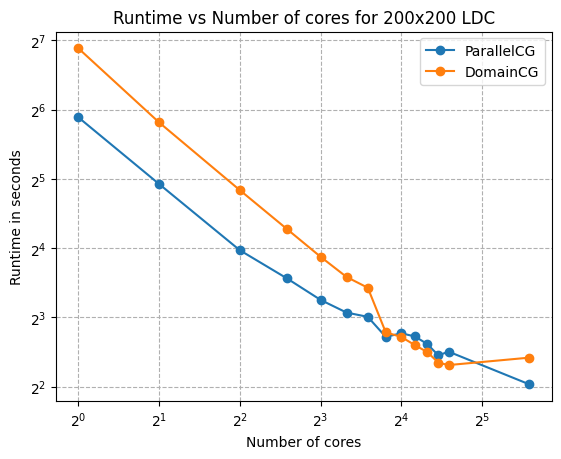

<Figure size 640x480 with 0 Axes>

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.plot(node_numbers_cg, times_cg, marker='o', label='ParallelCG')
plt.plot(node_numbers_cg_domain, times_cg_domain, marker='o', label='DomainCG')
plt.yscale('log', base=2)
plt.xscale('log', base=2)
plt.xlabel('Number of cores')
plt.ylabel('Runtime in seconds')
plt.title('Runtime vs Number of cores for 200x200 LDC')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()

# save plot as vector graphic with high quality
plt.savefig('runtime_vs_cores.png', format='png', dpi=300)

### Speed up plot

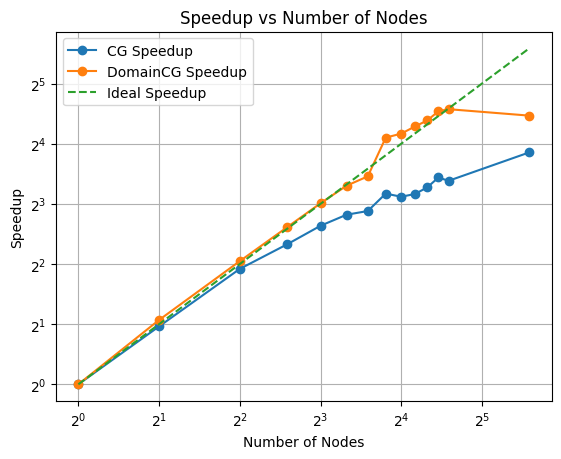

/tmp/ipykernel_344646/395418430.py:23: RuntimeWarning: invalid value encountered in divide
  s_cg = (np.array(node_numbers_cg) / speed_up_cg - 1) / (np.array(node_numbers_cg) - 1)
/tmp/ipykernel_344646/395418430.py:27: RuntimeWarning: invalid value encountered in divide
  s_cg_domain = (np.array(node_numbers_cg_domain) / speed_up_cg_domain - 1) / (np.array(node_numbers_cg_domain) - 1)


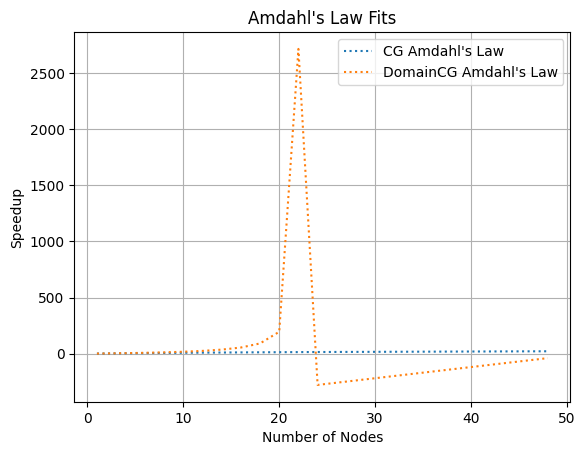

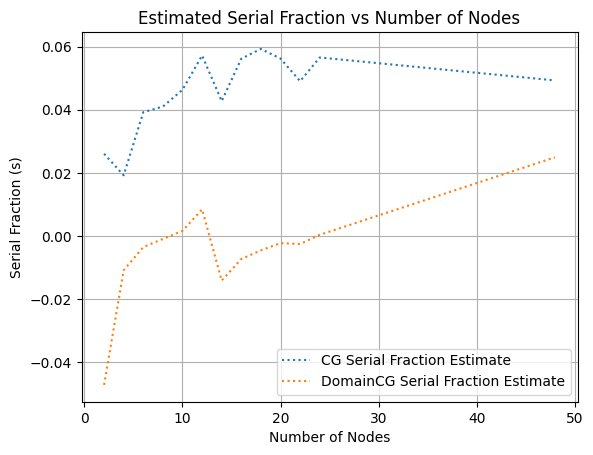

In [3]:
# Speedup
speed_up_cg = times_cg[0] / np.array(times_cg)
speed_up_cg_domain = times_cg_domain[0] / np.array(times_cg_domain)

nodes_all = np.array(sorted(set(node_numbers_cg) | set(node_numbers_cg_domain)))

plt.figure()
plt.plot(node_numbers_cg, speed_up_cg, marker='o', label='CG Speedup')
plt.plot(node_numbers_cg_domain, speed_up_cg_domain, marker='o', label='DomainCG Speedup')
plt.plot(nodes_all, nodes_all, label='Ideal Speedup', linestyle='--')
plt.xscale('log', base=2)
plt.yscale('log', base=2)
plt.xlabel('Number of Nodes')
plt.ylabel('Speedup')
plt.title('Speedup vs Number of Nodes')
plt.legend()
plt.grid(True)
plt.show()

# Serial fraction + Amdahl's law for both datasets
plt.figure()

s_cg = (np.array(node_numbers_cg) / speed_up_cg - 1) / (np.array(node_numbers_cg) - 1)
amdahls_speedup_cg = 1 / (s_cg[1] + (1 - s_cg[1]) / np.array(node_numbers_cg))
plt.plot(node_numbers_cg, amdahls_speedup_cg, label="CG Amdahl's Law", linestyle=':')

s_cg_domain = (np.array(node_numbers_cg_domain) / speed_up_cg_domain - 1) / (np.array(node_numbers_cg_domain) - 1)
amdahls_speedup_cg_domain = 1 / (s_cg_domain[1] + (1 - s_cg_domain[1]) / np.array(node_numbers_cg_domain))
plt.plot(node_numbers_cg_domain, amdahls_speedup_cg_domain, label="DomainCG Amdahl's Law", linestyle=':')

plt.xlabel('Number of Nodes')
plt.ylabel('Speedup')
plt.title("Amdahl's Law Fits")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(node_numbers_cg, s_cg, label='CG Serial Fraction Estimate', linestyle=':')
plt.plot(node_numbers_cg_domain, s_cg_domain, label='DomainCG Serial Fraction Estimate', linestyle=':')
plt.xlabel('Number of Nodes')
plt.ylabel('Serial Fraction (s)')
plt.title('Estimated Serial Fraction vs Number of Nodes')
plt.legend()
plt.grid(True)
plt.show()

### Parallel efficiency plot

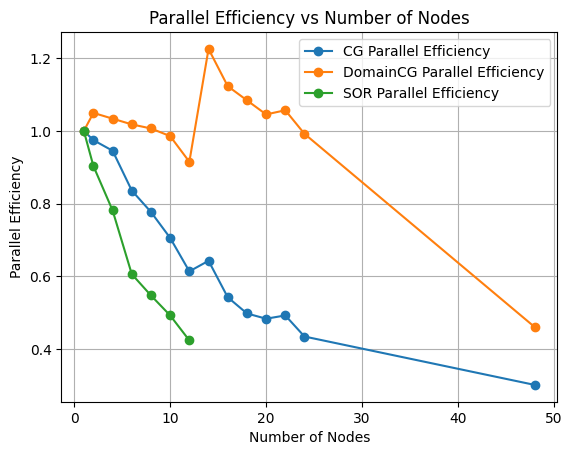

In [ ]:
parallel_efficiency_cg = speed_up_cg / np.array(node_numbers_cg)
parallel_efficiency_cg_domain = speed_up_cg_domain / np.array(node_numbers_cg_domain)


plt.figure()
plt.plot(node_numbers_cg, parallel_efficiency_cg, marker='o', label='CG Parallel Efficiency')
plt.plot(node_numbers_cg_domain, parallel_efficiency_cg_domain, marker='o', label='DomainCG Parallel Efficiency')
plt.xlabel('Number of Nodes')
plt.ylabel('Parallel Efficiency')
plt.title('Parallel Efficiency vs Number of Nodes')
plt.legend()
plt.grid(True)
plt.show()

3. How is the strong scaling of your program?

It is goooooooooood